# Why real wings aren't elliptical

Lifting-line theory says the elliptical spanwise loading minimises induced drag at fixed lift. Almost nothing since the Spitfire uses it. The standard result treats the wing as a pure aerodynamic object, but a wing is also a cantilever beam, and lift near the tip has a long moment arm about the root. The elliptical optimum is optimal only if structure is free.

**Method.** Circulation as a Fourier sine series under $y = -\frac{b}{2}\cos\theta$, so $C_L = \pi\,AR\,A_1$ depends on the first harmonic alone while $C_{D,i} = \pi\,AR\sum_n n A_n^2$ depends on all of them. Minimising drag subject to fixed lift *and* fixed bending moment is then a quadratic objective with a linear constraint, so Lagrange multipliers give a closed form. No solver, nothing to converge. Two bending criteria: root (moment arm $y$) and integrated (moment arm $y^2$).

**Validation.** Under integrated bending at $f = 2/3$ the optimiser returns $A_3/A_1 = -1/3$ with all higher harmonics at machine zero — Prandtl's 1933 bell, recovered from code containing no reference to it. Influence coefficients also match an analytic form,

$$I_n = -\frac{(-1)^{(n-1)/2}}{n^2 - 4}$$

to better than $10^{-9}$.

**Results.** The penalty is exactly quadratic in the relief demanded:

$$\frac{C_{D,i}}{C_{D,i,\text{ell}}} = 1 + c\,(1-f)^2, \qquad c = \frac{C_1^2}{2\sum_{n\geq 3} C_n^2/(2n)}$$

confirmed against 62 independently computed rows to machine precision. $c_I = 8$ and $c_K = 3$, both exact, so root bending costs $8/3$ times more per unit relief.

Two things follow. Under integrated bending $A_3/A_1 = f - 1$ exactly, so the optima form a one-parameter family and Prandtl's bell is simply where $f = 2/3$ lands — not a distinguished shape. And under root bending the bell is beaten: at identical lift and identical root bending it gives $1.3333$ against the optimum's $1.3207$.

**Limitations.** This optimises the loading, not the wing — recovering a planform and twist that produce a given $\Gamma(y)$ is the inverse problem and is underdetermined. Bending moment is a proxy for structural cost, not structural cost. Inviscid throughout; adding profile drag requires committing to a planform, which leaves the loading-level framework entirely.

bell, two constructions agree to: 4.44e-16
C_L elliptical: 25.132741   C_L bell: 25.132741
C_Di ratio, bell over elliptical: 1.333333
I_1 =  0.333333
I_3 =  0.200000
I_5 = -0.047619
I_7 =  0.022222
K_1 =  1.963495e-01
K_3 =  1.963495e-01
K_5 = -3.469447e-18
K_7 =  0.000000e+00
K_9 = -6.938894e-18
K_11 =  3.469447e-18
closed form for I_n confirmed against numerical integration
bending ratio, bell over elliptical: 0.800000
root optimum at f=0.80, bending ratio: 0.800000
root optimum at f=0.80, drag ratio:    1.320727
f = 0.9000   A_3/A_1 = -0.100000
f = 0.6667   A_3/A_1 = -0.333333
f = 0.5000   A_3/A_1 = -0.500000

ROOT bending constraint
     f   C_Di ratio    A_3/A_1   bending         e
  1.00     1.000000   0.000000    1.0000    1.0000
  0.99     1.000802  -0.016036    0.9900    0.9992
  0.98     1.003207  -0.032073    0.9800    0.9968
  0.97     1.007216  -0.048109    0.9700    0.9928
  0.96     1.012829  -0.064145    0.9600    0.9873
  0.95     1.020045  -0.080182    0.9500    0.980

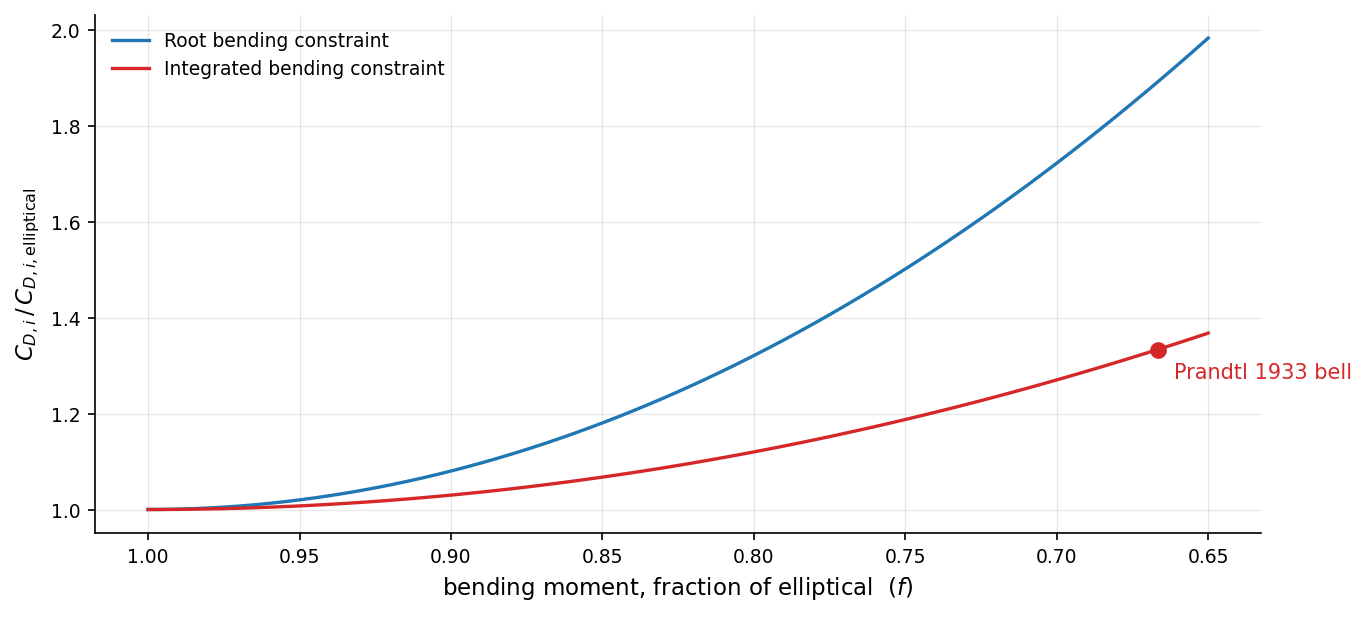

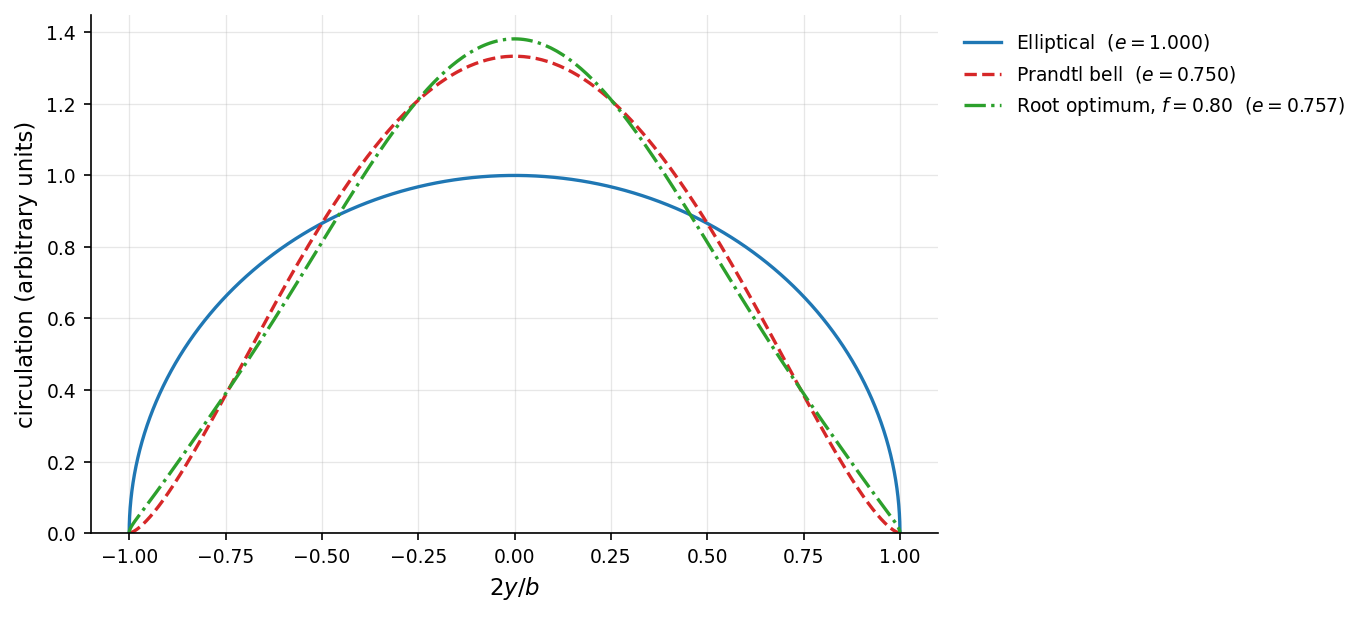

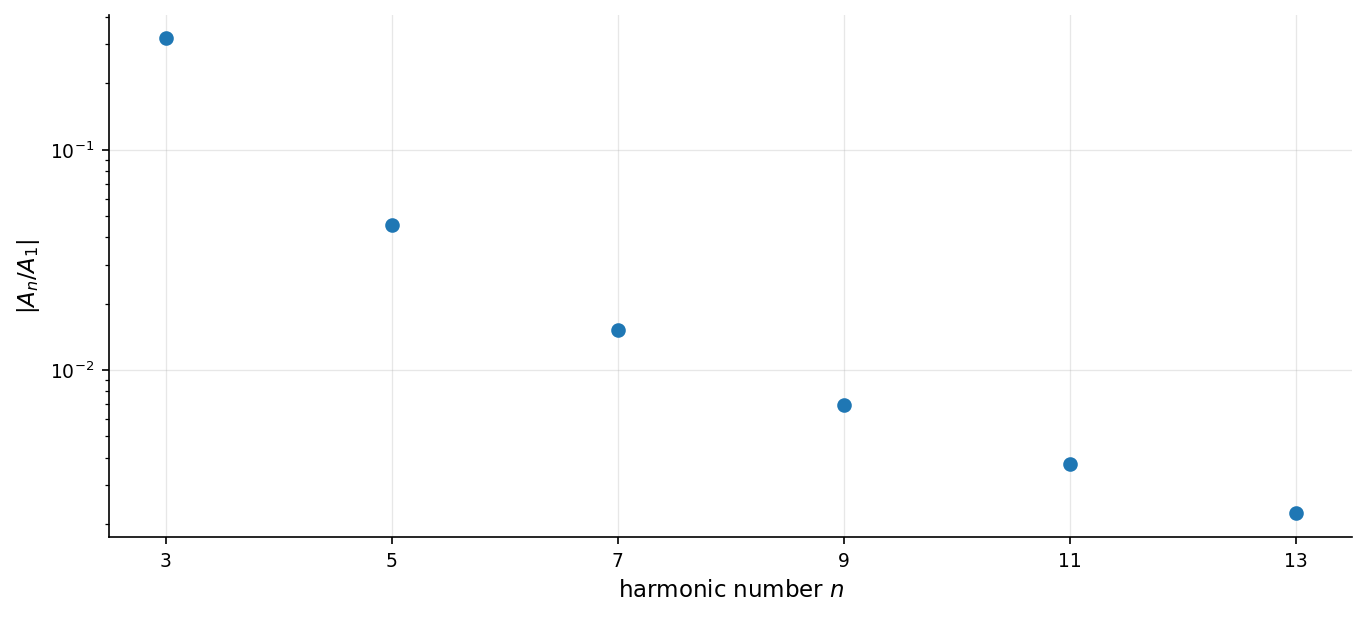

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

plt.rcParams.update({
    "figure.figsize": (9, 4),
    "figure.dpi": 150,
    # 150 on screen. matplotlib's default 100 looks soft

    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    # crops whitespace and stops a legend placed outside the axes being cut off

    "font.size": 10,
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    # labels slightly larger than ticks. ticks are reference, labels are read

    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linewidth": 0.6,
    "axes.axisbelow": True,
    # axisbelow puts the grid behind the data, not over the curves

    "legend.frameon": False,
    "lines.linewidth": 1.6,

    "axes.spines.top": False,
    "axes.spines.right": False,
    # more ink on the data, less on the box

    "figure.constrained_layout.use": True,
})


def save_fig(fig, name):
    # writes to figures/ so the README can reference stable paths.
    # dpi and bbox come from rcParams, so they cannot drift between figures
    os.makedirs("figures", exist_ok=True)
    fig.savefig(f"figures/{name}.png")


theta = np.linspace(0, np.pi, 401)
# theta is a relabelling of position. theta=0 is left wingtip, theta=pi/2 is centre,
# theta=pi is right wingtip. sin(n*theta) vanishes at both tips for every n, so the
# boundary condition is built into the basis

eta = -np.cos(theta)
# normalised position, eta = 2y/b, from -1 to 1. shape not size


def gamma_theta(A, theta):
    # spanwise circulation from a dict of Fourier coefficients
    total = np.zeros_like(theta)
    for n, An in A.items():
        total = total + (An * np.sin(n * theta))
        # dropped 2bV_inf as it is constant in all cases and cancels in every ratio
    return total


bell_fourier = gamma_theta({1: 1.0, 3: -1/3}, theta)
bell_direct = (4/3) * np.sin(theta)**3
# same curve two ways. sin^3(theta) = (3 sin(theta) - sin(3 theta))/4, so the Fourier
# pair {1, -1/3} must reproduce it. validates the series machinery before anything
# is built on it

ell = gamma_theta({1: 1.0}, theta)
# elliptical loading. one harmonic only. baseline for every comparison

print(f"bell, two constructions agree to: {np.abs(bell_fourier - bell_direct).max():.2e}")


def CL(A, AR):
    # depends on the first harmonic alone. lift is linear in the series, and every
    # sin(n*theta) for n > 1 is orthogonal to the sin(theta) from dy, so it integrates
    # to zero. higher harmonics move lift along the span, they never add any
    return np.pi * AR * A[1]


def CDi(A, AR):
    # depends on every harmonic, weighted by n. drag is quadratic - circulation against
    # the downwash it generates - so orthogonality leaves the squares instead of
    # cancelling them. the extra n comes from the downwash being built from dGamma/dy
    total = 0
    for n, An in A.items():
        total = total + (n * An**2)
        # squared, so every harmonic adds drag. sign cannot help you
    return np.pi * AR * total
    # pi * AR pulled outside the loop. constant, applied once


A_ell = {1: 1.0}
A_bell = {1: 1.0, 3: -1/3}
# coefficient dicts. A_ prefix so they are never confused with the curves ell and bell

print(f"C_L elliptical: {CL(A_ell, 8):.6f}   C_L bell: {CL(A_bell, 8):.6f}")
print(f"C_Di ratio, bell over elliptical: {CDi(A_bell, 8) / CDi(A_ell, 8):.6f}")
# C_L identical, C_Di ratio 1.3333. same lift, 33% more drag: why the bell loses
# at fixed span


def bending_coeffs(n_b, kind, N=20001):
    # how much bending one unit of each harmonic produces
    theta_b = np.linspace(np.pi/2, np.pi, N)
    # right half span only. y is odd, so the full span would cancel to zero

    if kind == "root":
        weight = -np.cos(theta_b)
        # moment arm y. gives I_n, the peak moment carried at the wing-fuselage junction
    elif kind == "integrated":
        weight = np.cos(theta_b)**2
        # moment arm y squared. gives K_n, bending summed along the span, a proxy for
        # total spar material rather than the single worst point
    else:
        raise ValueError(f"kind must be 'root' or 'integrated', got {kind!r}")
        # catches typos like "Root" instead of a confusing NameError later

    bending_moment = {}
    for n in n_b:
        bending_moment[n] = np.trapezoid(np.sin(n * theta_b) * weight * np.sin(theta_b), theta_b)
        # three factors: the harmonic, the moment arm, and sin(theta) from
        # dy = (b/2) sin(theta) d theta. the moment arm sits between the two sines and
        # breaks orthogonality, which is what makes these coefficients nonzero
    return bending_moment


I = bending_coeffs([1, 3, 5, 7], "root")
K = bending_coeffs([1, 3, 5, 7, 9, 11], "integrated")

for n in I: print(f"I_{n} = {I[n]: .6f}")
for n in K: print(f"K_{n} = {K[n]: .6e}")
# I_n must be 1/3, 1/5, -1/21, 1/45. K_1 = K_3 = pi/16 with K_n = 0 for every n >= 5:
# integrated bending is blind to harmonics above the third
# .6e on K so a true zero can be told apart from a rounding artifact


def I_closed(n):
    # analytic form of the root-bending influence coefficient, from product-to-sum on
    # sin(n theta) sin(2 theta). the upper limit vanishes and only theta = pi/2 survives.
    # odd n only; n = 2 would divide by zero
    return -(-1)**((n - 1)//2) / (n**2 - 4)


I_check = bending_coeffs(list(range(1, 14, 2)), "root")
for n in I_check:
    assert abs(I_closed(n) - I_check[n]) < 1e-9, f"I_n mismatch at n={n}"
    # 1e-9 not 1e-15. trapezoid has finite resolution, so demanding machine precision
    # would test the integrator rather than the formula
print("closed form for I_n confirmed against numerical integration")

B_bell = sum(A_bell[n] * I[n] for n in A_bell)
B_ell = sum(A_ell[n] * I[n] for n in A_ell)
print(f"bending ratio, bell over elliptical: {(B_bell / B_ell):.6f}")
# bending is now a weighted sum, no integral needed. this is what the coefficients
# bought us. 0.80 exactly, which is why f = 0.80 is the fair comparison point below


def optimize(C, f, A1=1.0):
    # least-drag coefficients at bending fraction f. C is I or K, f is the bending
    # allowed as a fraction of elliptical, A1 is pinned by lift and never optimised

    free = [n for n in C if n != 1]
    # harmonics actually being optimised. A_1 is fixed by the lift requirement so it is
    # excluded from every sum, but still goes in the output dict

    denom = sum(C[n]**2/(2 * n) for n in free)
    # denominator of lambda. comes from substituting A_n = lam*C_n/(2n) back into the
    # constraint, so each harmonic contributes its influence squared over its drag cost

    if denom == 0:
        raise ValueError(
            "No free harmonic can move bending (all C_n == 0 for n in free); "
            f"keys passed: {list(C.keys())}"
        )
        # fires for K with keys above 3 only, where integrated bending is blind to every
        # free harmonic and no redistribution can reach the target

    lam = ((C[1] * A1) * (f - 1))/denom
    # exchange rate between bending and drag: how much drag one unit of relief costs.
    # negative for f < 1, which is what flips A_3 opposite in sign to C_3

    A = {1: A1}
    # seeded with the pinned harmonic first. building the free ones first and forgetting
    # this makes CDi return a wrong number silently instead of raising KeyError

    for n in free:
        A[n] = float((lam * C[n])/(2 * n))
        # the stationarity condition. A_n is proportional to C_n / n: a harmonic gets
        # used in proportion to the relief it buys and inversely to the drag it costs.
        # float() because trapezoid returns np.float64, which prints badly in a dict

    return A


A_opt = optimize(I, f=0.8)
# the optimum under root bending at 80% of elliptical. least drag for that budget
B = sum(A_opt[n] * I[n] for n in A_opt)

print(f"root optimum at f=0.80, bending ratio: {B / B_ell:.6f}")
print(f"root optimum at f=0.80, drag ratio:    {CDi(A_opt, 8) / CDi(A_ell, 8):.6f}")
# 1.3207 against the bell's 1.3333 at identical lift and identical root bending.
# the bell is optimal for integrated bending, not for every structural constraint

for f in [0.9, 2/3, 0.5]:
    A_test = optimize(K, f=f)
    print(f"f = {f:.4f}   A_3/A_1 = {A_test[3]/A_test[1]: .6f}")
# A_3/A_1 = f - 1 exactly, because K_1 = K_3 and every higher K_n is zero. the optima
# form a one-parameter family and Prandtl's bell is just where f = 2/3 lands


def sweep(C, B_ref, f_values, AR=8.0):
    # trade-off table for one bending criterion. C is I or K, B_ref is that criterion's
    # elliptical baseline. AR cancels in every ratio but is exposed as a parameter so
    # the invariance check below can vary it
    results = []
    for f in f_values:
        A_f = optimize(C, f=f)

        drag_f = CDi(A_f, AR) / CDi(A_ell, AR)
        # must be the same AR in both calls or the ratio is wrong and nothing complains

        a3_f = A_f[3] / A_f[1]
        # shape not size. dividing by A_1 makes it independent of the lift level

        bend_f = sum(A_f[n] * C[n] for n in A_f) / B_ref
        # C and B_ref must be the same criterion, or this compares root bending against
        # an integrated baseline

        assert abs(bend_f - f) < 1e-10, f"bending mismatch at f={f:.2f}: got {bend_f}"
        # the constraint imposed must be the constraint satisfied. the only check that
        # catches a sign error in lambda, which the drag column would happily hide

        delta_f = sum(n * (A_f[n]/A_f[1])**2 for n in A_f if n != 1)
        # fractional drag penalty above elliptical (Anderson, ch. 5). computed from the
        # coefficients rather than from drag_f so the assert below is a real check

        e_f = 1 / (1 + delta_f)

        assert abs(e_f * drag_f - 1) < 1e-12, f"span efficiency mismatch at f={f:.2f}"
        # two independent routes to the same physics. confirms the pi*AR prefactors
        # in CDi cancelled cleanly

        results.append({"f": f, "drag": drag_f, "a3_ratio": a3_f,
                        "bending": bend_f, "e": e_f})
        # one dict per row so the columns cannot drift out of sync
    return results


def print_table(results, label):
    # both sweeps print identically, so the formatting lives in one place
    print(f"\n{label}")
    print(f"{'f':>6}  {'C_Di ratio':>11}  {'A_3/A_1':>9}  {'bending':>8}  {'e':>8}")
    for r in results:
        print(f"{r['f']:>6.2f}  {r['drag']:>11.6f}  {r['a3_ratio']:>9.6f}  "
              f"{r['bending']:>8.4f}  {r['e']:>8.4f}")
        # right-aligned so a non-monotonic row is visible at a glance


B_ell_K = sum(A_ell[n] * K[n] for n in A_ell)
# elliptical's bending under the integrated criterion. B_ell is the root-bending
# baseline, so the two are not interchangeable

f_table = np.linspace(1.00, 0.70, 31)
# linspace not arange. arange accumulates float error and its stop value is exclusive

results_I = sweep(I, B_ell, f_table)
results_K = sweep(K, B_ell_K, f_table)

print_table(results_I, "ROOT bending constraint")
print_table(results_K, "INTEGRATED bending constraint")


def trade_coeff(C):
    # the coefficient c in CDi/CDi_ell = 1 + c(1-f)^2. bending the pinned harmonic
    # forces, over the leverage the free ones can offer, each discounted by its drag cost
    free = [n for n in C if n != 1]
    denom = sum(C[n]**2/(2 * n) for n in free)
    # same construction as optimize. kept duplicated rather than factored out; if one
    # changes the other must
    return (C[1]**2)/(2 * denom)


c_I = trade_coeff(I)
c_K = trade_coeff(K)
print(f"\nc_I = {c_I:.6f}   c_K = {c_K:.6f}")
# root bending costs 8/3 times more per unit relief than integrated bending

for r in results_I:
    assert abs(1 + c_I * (r["f"] - 1)**2 - r["drag"]) < 1e-10, \
        f"closed form disagrees at f={r['f']:.2f}"
for r in results_K:
    assert abs(1 + c_K * (r["f"] - 1)**2 - r["drag"]) < 1e-10, \
        f"closed form disagrees at f={r['f']:.2f}"
# all 62 rows against a formula derived independently of the loop that produced them

check_at = [0.90, 0.80, 0.70]
for label, results, c in [("ROOT", results_I, c_I), ("INTEGRATED", results_K, c_K)]:
    print(f"\n{label}")
    print(f"{'f':>6}  {'computed':>10}  {'closed form':>12}  {'diff':>10}")
    for r in results:
        if any(abs(r["f"] - t) < 1e-9 for t in check_at):
            pred = 1 + c * (r["f"] - 1)**2
            print(f"{r['f']:>6.2f}  {r['drag']:>10.6f}  {pred:>12.6f}  "
                  f"{abs(pred - r['drag']):>10.2e}")
            # scientific notation so machine precision reads as 1e-16, not 0.00

# ---- truncation: how far the series must be carried

print(f"\n{'top n':>6}  {'c_I':>12}  {'change':>10}")
prev = None
for top in [7, 9, 11, 13, 21, 51]:
    c_trunc = trade_coeff(bending_coeffs(list(range(1, top + 1, 2)), "root"))
    # only c is needed, not a full sweep. c fixes the entire curve, so showing c has
    # converged shows the whole trade-off has

    change = "" if prev is None else f"{abs(c_trunc - prev)/prev * 100:>9.4f}%"
    print(f"{top:>6}  {c_trunc:>12.6f}  {change:>10}")
    # change is per level, not per harmonic. the levels are unevenly spaced, so the
    # last two rows span four harmonics each rather than one
    prev = c_trunc

c_7 = trade_coeff(bending_coeffs(list(range(1, 8, 2)), "root"))
c_51 = trade_coeff(bending_coeffs(list(range(1, 52, 2)), "root"))
print(f"truncating at n=7 overestimates c by {(c_7 - c_51)/c_51 * 100:.3f}%")

for top in [7, 51, 201, 801]:
    denom = sum(I_closed(n)**2/(2 * n) for n in range(3, top + 1, 2))
    print(f"{top:>4}  c_I = {(1/3)**2 / (2 * denom):.10f}")
    # the closed form lets the sum run far past anything trapezoid could resolve.
    # c_I is exactly 8, so c_I / c_K is exactly 8/3

# ---- compressibility: the result does not depend on Mach or aspect ratio

ref = [r["drag"] for r in results_I]
for M in [0.0, 0.3, 0.6, 0.8]:
    beta = np.sqrt(1 - M**2)
    # subsonic compressible flow maps to an equivalent incompressible problem with the
    # aspect ratio scaled by beta

    test = [r["drag"] for r in sweep(I, B_ell, f_table, AR=8.0 * beta)]
    worst = max(abs(a - b) for a, b in zip(ref, test))

    print(f"M = {M:.1f}   beta*AR = {8*beta:.3f}   max drag-ratio difference = {worst:.2e}")
    assert worst < 1e-12, f"AR dependence leaked in at M={M}"
    # confirms the premise the argument rests on: nothing in the optimisation sees AR.
    # the optimal loading is Mach-invariant subcritically; the wing producing it is not

# ---- figures

f_plot = np.linspace(1.00, 0.65, 71)
# wider than f_table because the bell sits at f = 2/3, below the 0.70 floor.
# finer too, since this is drawn rather than read

plot_I = sweep(I, B_ell, f_plot)
plot_K = sweep(K, B_ell_K, f_plot)
# same function as the tables, so the figure and the numbers cannot disagree

f_bell = 2/3
drag_bell = 1 + c_K * (f_bell - 1)**2
# computed from c_K, not hardcoded as 4/3, so the marker tracks anything upstream

fig, ax = plt.subplots()
ax.plot([r["f"] for r in plot_I], [r["drag"] for r in plot_I],
        color="C0", label="Root bending constraint")
ax.plot([r["f"] for r in plot_K], [r["drag"] for r in plot_K],
        color="C3", label="Integrated bending constraint")
ax.plot(f_bell, drag_bell, "o", color="C3", ms=7, zorder=5)
# zorder above the lines so the marker is not half-buried by the curve

ax.annotate("Prandtl 1933 bell", xy=(f_bell, drag_bell),
            xytext=(8, -14), textcoords="offset points", color="C3")

ax.set_xlabel("bending moment, fraction of elliptical  ($f$)")
ax.set_ylabel(r"$C_{D,i} \, / \, C_{D,i,\mathrm{elliptical}}$")
ax.invert_xaxis()
# f decreases rightward, so more relief reads left-to-right and the cost rises

ax.legend(loc="upper left")
save_fig(fig, "tradeoff_two_criteria")

opt80 = gamma_theta(A_opt, theta)

e_opt = 1 / (1 + sum(n * (A_opt[n]/A_opt[1])**2 for n in A_opt if n != 1))
e_bell = 1 / (1 + sum(n * (A_bell[n]/A_bell[1])**2 for n in A_bell if n != 1))
# computed, not typed into the legend, so the labels cannot go stale

fig, ax = plt.subplots()
ax.plot(eta, ell, color="C0", label="Elliptical  ($e = 1.000$)")
ax.plot(eta, bell_fourier, "--", color="C3", label=f"Prandtl bell  ($e = {e_bell:.3f}$)")
ax.plot(eta, opt80, "-.", color="C2",
        label=f"Root optimum, $f = 0.80$  ($e = {e_opt:.3f}$)")

ax.set_xlabel("$2y/b$")
ax.set_ylabel("circulation (arbitrary units)")
ax.set_ylim(0, 1.45)
ax.axhline(0, color="0.5", lw=0.7)
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0))
save_fig(fig, "loading_shapes")
# the bell and the optimum are visually indistinguishable. a 1% drag difference does
# not show up to the eye

I_13 = bending_coeffs(list(range(1, 14, 2)), "root")
A_13 = optimize(I_13, f=0.8)
# out to n = 13 so the collapse spans two decades rather than one

harmonics = [n for n in A_13 if n != 1]
mags = [abs(A_13[n]/A_13[1]) for n in harmonics]

fig, ax = plt.subplots()
ax.plot(harmonics, mags, "o", color="C0", ms=6)
# markers not lines. n is discrete, and a connecting line implies values between them

ax.set_yscale("log")
ax.set_xticks(harmonics)
ax.set_xlabel("harmonic number $n$")
ax.set_ylabel(r"$|A_n / A_1|$")
save_fig(fig, "coefficient_collapse")